In [ ]:

!pip -q install kagglehub pydicom

import os
import gc
import glob
import random
import zipfile
import shutil
import subprocess
import warnings
import re

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
import pydicom

from pydicom.pixels import apply_voi_lut

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import kagglehub

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 20

CLASS_NAMES = [
    "Adenocarcinoma",
    "Large Cell Carcinoma",
    "Squamous Cell Carcinoma"
]

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Classes:", CLASS_NAMES)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 83.0 MB/s eta 0:00:00
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Classes: ['Adenocarcinoma', 'Large Cell Carcinoma', 'Squamous Cell Carcinoma']


In [ ]:
WORK_DIR = "/content/lung_cancer_project"
os.makedirs(WORK_DIR, exist_ok=True)

print("=" * 70)
print("DOWNLOADING / LOCATING CT-PET DATASET")
print("=" * 70)

CTPET_PATH = kagglehub.dataset_download(
    "sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format"
)

print("CT-PET path:")
print(CTPET_PATH)

print("\n" + "=" * 70)
print("DOWNLOADING / LOCATING EXTERNAL CHEST CT DATASET")
print("=" * 70)

EXTERNAL_PATH = kagglehub.dataset_download(
    "mohamedhanyyy/chest-ctscan-images"
)

print("External Chest CT path:")
print(EXTERNAL_PATH)

print("\n" + "=" * 70)
print("LOCATING FIGSHARE ZIP")
print("=" * 70)

# Look for ZIP files uploaded directly into /content.
content_zip_candidates = sorted(
    glob.glob("/content/*.zip")
)

if not content_zip_candidates:
    content_zip_candidates = sorted(
        glob.glob("/content/*/*.zip")
    )

# Prefer a filename containing "lung" or "cancer".
preferred = [
    p for p in content_zip_candidates
    if "lung" in os.path.basename(p).lower()
    or "cancer" in os.path.basename(p).lower()
]

if preferred:
    FIGSHARE_ZIP = preferred[0]
elif content_zip_candidates:
    FIGSHARE_ZIP = content_zip_candidates[0]
else:
    FIGSHARE_ZIP = None

# If a user-uploaded ZIP exists, verify it before doing anything else.
if FIGSHARE_ZIP is not None:
    print("Candidate uploaded ZIP:")
    print(FIGSHARE_ZIP)

    if not zipfile.is_zipfile(FIGSHARE_ZIP):
        raise RuntimeError(
            "\nA .zip file was found, but it is NOT a valid ZIP archive.\n"
            f"File: {FIGSHARE_ZIP}\n\n"
            "Please re-upload the original Figshare ZIP file in Colab.\n"
            "Do not rename a non-ZIP file to .zip."
        )

    print("Valid ZIP archive confirmed.")

else:
    # Only use the Figshare download as a fallback if no uploaded ZIP exists.
    print("No uploaded Figshare ZIP was found in /content.")
    print("Downloading the Figshare file as a fallback...")

    FIGSHARE_ZIP = os.path.join(
        WORK_DIR,
        "Lung Cancer Detection - Dataset.zip"
    )

    FIGSHARE_URL = (
        "https://figshare.com/ndownloader/files/52627007"
    )

    response = subprocess.run(
        [
            "wget",
            "-q",
            "--show-progress",
            "-O",
            FIGSHARE_ZIP,
            FIGSHARE_URL
        ],
        check=False
    )

    if response.returncode != 0:
        raise RuntimeError(
            "Figshare download failed. "
            "Please upload the ZIP manually to Colab."
        )

    if not zipfile.is_zipfile(FIGSHARE_ZIP):
        # Delete the invalid download so it cannot be reused accidentally.
        try:
            os.remove(FIGSHARE_ZIP)
        except OSError:
            pass

        raise RuntimeError(
            "\nThe Figshare URL did not return a valid ZIP archive.\n"
            "Please upload the Figshare ZIP manually to Colab."
        )

    print("Downloaded file is a valid ZIP.")



FIGSHARE_EXTRACT = os.path.join(
    WORK_DIR,
    "figshare_extracted"
)

# incomplete extraction cannot produce zero class folders.
if os.path.isdir(FIGSHARE_EXTRACT):
    shutil.rmtree(FIGSHARE_EXTRACT)

os.makedirs(
    FIGSHARE_EXTRACT,
    exist_ok=True
)

print("\nExtracting:")
print(FIGSHARE_ZIP)

with zipfile.ZipFile(
    FIGSHARE_ZIP,
    "r"
) as z:

    bad_member = z.testzip()

    if bad_member is not None:
        raise RuntimeError(
            f"ZIP integrity check failed at: {bad_member}"
        )

    z.extractall(FIGSHARE_EXTRACT)

print("\nFigshare extraction completed.")

print("\nTop-level extracted contents:")
for item in sorted(os.listdir(FIGSHARE_EXTRACT)):
    print(" ", item)

print("\n" + "=" * 70)
print("DATASET PATHS")
print("=" * 70)
print("Figshare ZIP :", FIGSHARE_ZIP)
print("Figshare dir :", FIGSHARE_EXTRACT)
print("CT-PET       :", CTPET_PATH)
print("External CT  :", EXTERNAL_PATH)


DOWNLOADING / LOCATING CT-PET DATASET


100%|██████████| 1.12G/1.12G [00:57<00:00, 21.0MB/s]

Extracting files...


CT-PET path:
/root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2

DOWNLOADING / LOCATING EXTERNAL CHEST CT DATASET


100%|██████████| 119M/119M [00:07<00:00, 17.6MB/s]

Extracting files...


External Chest CT path:
/root/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1

LOCATING FIGSHARE ZIP
Candidate uploaded ZIP:
/content/Lung Cancer Detection - Dataset.zip
Valid ZIP archive confirmed.

Extracting:
/content/Lung Cancer Detection - Dataset.zip

Figshare extraction completed.

Top-level extracted contents:
  Lung Cancer Detection - Dataset

DATASET PATHS
Figshare ZIP : /content/Lung Cancer Detection - Dataset.zip
Figshare dir : /content/lung_cancer_project/figshare_extracted
CT-PET       : /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2
External CT  : /root/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1


In [ ]:


IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"
}

DICOM_EXTENSIONS = {
    ".dcm"
}

def collect_image_files(directory):
    files = []
    if not os.path.isdir(directory):
        return files

    for root, _, filenames in os.walk(directory):
        for filename in filenames:
            ext = os.path.splitext(filename)[1].lower()
            if ext in IMAGE_EXTENSIONS:
                files.append(os.path.join(root, filename))

    return sorted(files)


def collect_dicom_files(directory):
    files = []
    if not os.path.isdir(directory):
        return files

    for root, _, filenames in os.walk(directory):
        for filename in filenames:
            ext = os.path.splitext(filename)[1].lower()
            if ext in DICOM_EXTENSIONS or ext == "":
                # We only keep extensionless files if pydicom can read them later.
                if ext == ".dcm":
                    files.append(os.path.join(root, filename))
                elif "dicom" in root.lower():
                    files.append(os.path.join(root, filename))

    return sorted(set(files))


def print_tree(root, max_depth=3):
    root = os.path.abspath(root)
    for current, dirs, files in os.walk(root):
        depth = current.replace(root, "").count(os.sep)
        if depth > max_depth:
            dirs[:] = []
            continue

        indent = "  " * depth
        print(f"{indent}{os.path.basename(current)}/")

        if depth < max_depth:
            for f in sorted(files)[:10]:
                print(f"{indent}  {f}")

print("Helper functions ready.")


Helper functions ready.


In [ ]:


ctpet_class_dirs = {
    "A": [],
    "E": [],
    "G": []
}

for current, dirs, _ in os.walk(CTPET_PATH):

    base = os.path.basename(current).lower()

    if base in {
        "train",
        "val",
        "valid",
        "validation",
        "test"
    }:
        for d in dirs:
            key = d.upper()

            if key in ctpet_class_dirs:
                ctpet_class_dirs[key].append(
                    os.path.join(current, d)
                )

for key in ctpet_class_dirs:
    ctpet_class_dirs[key] = sorted(
        set(ctpet_class_dirs[key])
    )

print("=" * 70)
print("CT-PET CLASS DIRECTORIES")
print("=" * 70)

for key, dirs in ctpet_class_dirs.items():
    print(f"\nClass {key}:")
    for d in dirs:
        print(" ", d)

if any(len(v) == 0 for v in ctpet_class_dirs.values()):
    raise RuntimeError(
        "One or more required CT-PET classes were not found. "
        "Expected A (Adenocarcinoma), E (Large Cell), "
        "and G (Squamous)."
    )


CT-PET CLASS DIRECTORIES

Class A:
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/test/A
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/train/A
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/val/A

Class E:
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/test/E
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/train/E
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/val/E

Class G:
  /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/test/G
  /root/.cache/kaggle

In [ ]:

ctpet_records = []

ctpet_mapping = {
    "A": (0, "Adenocarcinoma"),
    "E": (1, "Large Cell Carcinoma"),
    "G": (2, "Squamous Cell Carcinoma")
}

for key, (label, class_name) in ctpet_mapping.items():

    for class_dir in ctpet_class_dirs[key]:

        for path in collect_dicom_files(class_dir):

            ctpet_records.append({
                "path": path,
                "label": label,
                "class_name": class_name,
                "format": "dicom",
                "source": "ctpet"
            })

ctpet_df = (
    pd.DataFrame(ctpet_records)
    .drop_duplicates(subset=["path"])
    .reset_index(drop=True)
)

print("=" * 70)
print("CT-PET TOTAL — THREE CLASSES")
print("=" * 70)

if len(ctpet_df):
    print(ctpet_df["class_name"].value_counts())
else:
    print("No DICOM files were found with the initial extension search.")

print("\nTotal:", len(ctpet_df))


CT-PET TOTAL — THREE CLASSES
class_name
Adenocarcinoma             3000
Squamous Cell Carcinoma    1000
Large Cell Carcinoma         50
Name: count, dtype: int64

Total: 4050


In [ ]:


if len(ctpet_df) == 0:

    print("Trying robust DICOM discovery...")

    robust_records = []

    for current, _, filenames in os.walk(CTPET_PATH):

        base = os.path.basename(current).upper()

        if base not in {"A", "E", "G"}:
            continue

        label, class_name = ctpet_mapping[base]

        for filename in filenames:

            path = os.path.join(current, filename)

            try:

                ds = pydicom.dcmread(
                    path,
                    stop_before_pixels=True,
                    force=True
                )

                if hasattr(ds, "SOPClassUID") or hasattr(ds, "Rows"):

                    robust_records.append({
                        "path": path,
                        "label": label,
                        "class_name": class_name,
                        "format": "dicom",
                        "source": "ctpet"
                    })

            except Exception:
                pass

    ctpet_df = (
        pd.DataFrame(robust_records)
        .drop_duplicates(subset=["path"])
        .reset_index(drop=True)
    )

print("=" * 70)
print("FINAL CT-PET DISCOVERY")
print("=" * 70)

print("Total:", len(ctpet_df))

if len(ctpet_df):
    print(ctpet_df["class_name"].value_counts())

required_labels = {0, 1, 2}

if set(ctpet_df["label"].unique()) != required_labels:
    raise RuntimeError(
        "CT-PET discovery did not find all three required classes."
    )


FINAL CT-PET DISCOVERY
Total: 4050
class_name
Adenocarcinoma             3000
Squamous Cell Carcinoma    1000
Large Cell Carcinoma         50
Name: count, dtype: int64


In [ ]:

train_parts = []
val_parts = []

for label in range(NUM_CLASSES):

    class_df = (
        train_pool_df[
            train_pool_df["label"] == label
        ]
        .sample(
            frac=1,
            random_state=SEED
        )
        .reset_index(drop=True)
    )

    class_train, class_val = train_test_split(
        class_df,
        test_size=0.20,
        random_state=SEED,
        shuffle=True
    )

    train_parts.append(class_train)
    val_parts.append(class_val)

train_df = (
    pd.concat(train_parts, ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

val_df = (
    pd.concat(val_parts, ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("=" * 70)
print("80:20 STRATIFIED TRAIN / VALIDATION SPLIT")
print("=" * 70)

print("\nTraining:")
print(train_df["class_name"].value_counts())

print("\nValidation:")
print(val_df["class_name"].value_counts())

print("\nShapes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)


80:20 STRATIFIED TRAIN / VALIDATION SPLIT

Training:
class_name
Adenocarcinoma             2622
Squamous Cell Carcinoma     972
Large Cell Carcinoma        168
Name: count, dtype: int64

Validation:
class_name
Adenocarcinoma             656
Squamous Cell Carcinoma    243
Large Cell Carcinoma        43
Name: count, dtype: int64

Shapes:
Train: (3762, 6)
Val  : (942, 6)


In [ ]:


def load_dicom_image(path):

    ds = pydicom.dcmread(
        path,
        force=True
    )

    try:
        image = apply_voi_lut(
            ds.pixel_array,
            ds
        )
    except Exception:
        image = ds.pixel_array

    image = np.asarray(
        image,
        dtype=np.float32
    )

    image = np.squeeze(image)

    # Handle multiframe DICOM.
    if image.ndim == 3:

        # RGB image
        if image.shape[-1] == 3:
            image = cv2.cvtColor(
                image.astype(np.float32),
                cv2.COLOR_RGB2GRAY
            )

        # Multiframe grayscale -> central slice/frame.
        else:
            image = image[
                image.shape[0] // 2
            ]

    if image.ndim != 2:
        raise ValueError(
            f"Unexpected DICOM shape {image.shape} for {path}"
        )

    # Apply modality transform where available.
    slope = float(
        getattr(ds, "RescaleSlope", 1.0)
    )
    intercept = float(
        getattr(ds, "RescaleIntercept", 0.0)
    )

    image = image * slope + intercept

    # Correct MONOCHROME1 polarity.
    if getattr(
        ds,
        "PhotometricInterpretation",
        ""
    ) == "MONOCHROME1":

        image = np.max(image) - image

    # Robust percentile normalization.
    low, high = np.percentile(
        image,
        [1, 99]
    )

    if high > low:
        image = (
            image - low
        ) / (
            high - low
        )
    else:
        image = np.zeros_like(
            image,
            dtype=np.float32
        )

    image = np.clip(
        image,
        0.0,
        1.0
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    image = np.stack(
        [image, image, image],
        axis=-1
    )

    return image.astype(np.float32)


def load_normal_image(path):

    image = cv2.imread(
        path,
        cv2.IMREAD_COLOR
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    image = (
        image.astype(np.float32)
        / 255.0
    )

    return image


def load_sample(path, file_format):

    if file_format == "dicom":
        image = load_dicom_image(path)

    elif file_format == "image":
        image = load_normal_image(path)

    else:
        raise ValueError(
            f"Unknown format: {file_format}"
        )

    if image.shape != (
        IMG_SIZE,
        IMG_SIZE,
        3
    ):
        raise ValueError(
            f"Invalid image shape {image.shape}: {path}"
        )

    return image.astype(np.float32)


print("Preprocessing functions ready.")


Preprocessing functions ready.


In [ ]:

class MixedImageSequence(
    keras.utils.Sequence
):

    def __init__(
        self,
        dataframe,
        batch_size=16,
        shuffle=True,
        augment=False,
        class_weights=None,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.class_weights = class_weights

        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(
            np.ceil(
                len(self.df) / self.batch_size
            )
        )

    def _augment(self, image):

        if np.random.rand() < 0.50:
            image = cv2.flip(image, 1)

        if np.random.rand() < 0.30:

            angle = np.random.uniform(-7, 7)

            matrix = cv2.getRotationMatrix2D(
                (IMG_SIZE / 2, IMG_SIZE / 2),
                angle,
                1.0
            )

            image = cv2.warpAffine(
                image,
                matrix,
                (IMG_SIZE, IMG_SIZE),
                borderMode=cv2.BORDER_REFLECT_101
            )

        if np.random.rand() < 0.30:

            alpha = np.random.uniform(0.90, 1.10)
            beta = np.random.uniform(-0.04, 0.04)

            image = np.clip(
                image * alpha + beta,
                0,
                1
            )

        return image.astype(np.float32)

    def __getitem__(self, index):

        batch_indices = self.indices[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        batch = self.df.iloc[batch_indices]

        X = []
        y = []

        for _, row in batch.iterrows():

            try:

                image = load_sample(
                    row["path"],
                    row["format"]
                )

                if self.augment:
                    image = self._augment(image)

                X.append(image)
                y.append(int(row["label"]))

            except Exception as e:

                raise RuntimeError(
                    f"Failed to load: {row['path']}\n"
                    f"Reason: {e}"
                )

        X = np.stack(X, axis=0).astype(np.float32)

        y = keras.utils.to_categorical(
            y,
            num_classes=NUM_CLASSES
        ).astype(np.float32)

        return X, y

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)


class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

target_count = class_counts.max()

balanced_parts = []

for label in range(NUM_CLASSES):

    part = train_df[
        train_df["label"] == label
    ]

    part = part.sample(
        n=target_count,
        replace=(len(part) < target_count),
        random_state=SEED
    )

    balanced_parts.append(part)

balanced_train_df = (
    pd.concat(
        balanced_parts,
        ignore_index=True
    )
    .sample(
        frac=1,
        random_state=SEED
    )
    .reset_index(drop=True)
)

print("Original train size :", len(train_df))
print("Balanced train size :", len(balanced_train_df))
print(
    balanced_train_df["class_name"].value_counts()
)


Original train size : 3762
Balanced train size : 7866
class_name
Large Cell Carcinoma       2622
Adenocarcinoma             2622
Squamous Cell Carcinoma    2622
Name: count, dtype: int64


In [ ]:

train_gen = MixedImageSequence(
    balanced_train_df,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True
)

val_gen = MixedImageSequence(
    val_df,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

X_check, y_check = train_gen[0]

print("Train batch X:", X_check.shape)
print("Train batch y:", y_check.shape)
print("X dtype:", X_check.dtype)
print("X range:", X_check.min(), X_check.max())
print("y example:", y_check[:3])


Train batch X: (16, 224, 224, 3)
Train batch y: (16, 3)
X dtype: float32
X range: 0.0 1.0
y example: [[1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [ ]:

from keras import Input
from keras.layers import (
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    DepthwiseConv2D,
    GlobalAveragePooling2D,
    Dense
)

input_layer = Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(input_layer)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2, 2)
)(x)

x = Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2, 2)
)(x)

block3_output = Conv2D(
    96,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

block3_output = BatchNormalization()(
    block3_output
)

block3_output = MaxPooling2D(
    (2, 2)
)(block3_output)

x = DepthwiseConv2D(
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)(block3_output)

x = Conv2D(
    128,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)

block4_branch = Conv2D(
    64,
    (1, 1),
    activation="relu",
    padding="same"
)(x)

x = Conv2D(
    160,
    (3, 3),
    activation="relu",
    padding="same"
)(block4_branch)

x = BatchNormalization()(x)

x = DepthwiseConv2D(
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)(x)

block4_output = DepthwiseConv2D(
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)(x)

x = MaxPooling2D(
    (2, 2)
)(block4_output)

x = DepthwiseConv2D(
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)(x)

x = Conv2D(
    192,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    96,
    (1, 1),
    activation="relu",
    padding="same"
)(x)

x = Conv2D(
    224,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)

x = DepthwiseConv2D(
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)(x)

x = DepthwiseConv2D(
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)(x)

main_branch_output = MaxPooling2D(
    (2, 2)
)(x)

main_branch_output = BatchNormalization()(
    main_branch_output
)

x = GlobalAveragePooling2D()(
    main_branch_output
)

output_layer = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs=input_layer,
    outputs=output_layer
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 28, 28, 96)     │           960 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 160)    │        92,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 160)    │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 28, 28, 160)    │         1,600 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 28, 28, 160)    │         1,600 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_3              │ (None, 14, 14, 160)    │         1,600 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 790,435 (3.02 MB)

 Trainable params: 788,195 (3.01 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [ ]:

import tensorflow as tf
from tensorflow import keras


class MacroPrecision(tf.keras.metrics.Metric):

    def __init__(self, num_classes, name="precision", **kwargs):
        super().__init__(name=name, **kwargs)

        self.num_classes = num_classes

        self.tp = self.add_weight(
            name="tp",
            shape=(num_classes,),
            initializer="zeros"
        )

        self.fp = self.add_weight(
            name="fp",
            shape=(num_classes,),
            initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):

        y_true = tf.argmax(
            y_true,
            axis=-1,
            output_type=tf.int32
        )

        y_pred = tf.argmax(
            y_pred,
            axis=-1,
            output_type=tf.int32
        )

        for c in range(self.num_classes):

            true_c = tf.equal(
                y_true,
                c
            )

            pred_c = tf.equal(
                y_pred,
                c
            )

            tp = tf.reduce_sum(
                tf.cast(
                    tf.logical_and(true_c, pred_c),
                    tf.float32
                )
            )

            fp = tf.reduce_sum(
                tf.cast(
                    tf.logical_and(
                        tf.logical_not(true_c),
                        pred_c
                    ),
                    tf.float32
                )
            )

            self.tp[c].assign_add(tp)
            self.fp[c].assign_add(fp)

    def result(self):

        precision = self.tp / (
            self.tp + self.fp + keras.backend.epsilon()
        )

        return tf.reduce_mean(precision)

    def reset_state(self):

        self.tp.assign(
            tf.zeros_like(self.tp)
        )

        self.fp.assign(
            tf.zeros_like(self.fp)
        )


class MacroRecall(tf.keras.metrics.Metric):

    def __init__(self, num_classes, name="recall", **kwargs):
        super().__init__(name=name, **kwargs)

        self.num_classes = num_classes

        self.tp = self.add_weight(
            name="tp",
            shape=(num_classes,),
            initializer="zeros"
        )

        self.fn = self.add_weight(
            name="fn",
            shape=(num_classes,),
            initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):

        y_true = tf.argmax(
            y_true,
            axis=-1,
            output_type=tf.int32
        )

        y_pred = tf.argmax(
            y_pred,
            axis=-1,
            output_type=tf.int32
        )

        for c in range(self.num_classes):

            true_c = tf.equal(
                y_true,
                c
            )

            pred_c = tf.equal(
                y_pred,
                c
            )

            tp = tf.reduce_sum(
                tf.cast(
                    tf.logical_and(true_c, pred_c),
                    tf.float32
                )
            )

            fn = tf.reduce_sum(
                tf.cast(
                    tf.logical_and(
                        true_c,
                        tf.logical_not(pred_c)
                    ),
                    tf.float32
                )
            )

            self.tp[c].assign_add(tp)
            self.fn[c].assign_add(fn)

    def result(self):

        recall = self.tp / (
            self.tp + self.fn + keras.backend.epsilon()
        )

        return tf.reduce_mean(recall)

    def reset_state(self):

        self.tp.assign(
            tf.zeros_like(self.tp)
        )

        self.fn.assign(
            tf.zeros_like(self.fn)
        )


class MacroSensitivity(MacroRecall):

    def __init__(
        self,
        num_classes,
        name="sensitivity",
        **kwargs
    ):
        super().__init__(
            num_classes=num_classes,
            name=name,
            **kwargs
        )


optimizer = keras.optimizers.Adam(
    learning_rate=5e-4
)

model.compile(

    optimizer=optimizer,

    loss=keras.losses.CategoricalCrossentropy(),

    metrics=[

        keras.metrics.CategoricalAccuracy(
            name="accuracy"
        ),

        keras.metrics.AUC(
            name="auc",
            multi_label=True,
            num_labels=NUM_CLASSES
        ),

        MacroPrecision(
            num_classes=NUM_CLASSES,
            name="precision"
        ),

        MacroRecall(
            num_classes=NUM_CLASSES,
            name="recall"
        ),

        keras.metrics.F1Score(
            name="f1_score",
            average="macro"
        ),

        MacroSensitivity(
            num_classes=NUM_CLASSES,
            name="sensitivity"
        )
    ]
)

print("Base model compiled successfully.")
print("Number of classes:", NUM_CLASSES)
print("Optimizer: Adam")
print("Learning rate: 5e-4")
print("Loss: Categorical Crossentropy")

Base model compiled successfully.
Number of classes: 3
Optimizer: Adam
Learning rate: 5e-4
Loss: Categorical Crossentropy


In [ ]:

INITIAL_LR = 5e-4

def lr_schedule(epoch, learning_rate):

    if epoch < 7:
        return learning_rate

    return learning_rate * 0.95


lr_callback = keras.callbacks.LearningRateScheduler(
    lr_schedule,
    verbose=1
)

best_checkpoint_path = os.path.join(
    WORK_DIR,
    "best_base_lung_cancer_model.keras"
)

final_checkpoint_path = os.path.join(
    WORK_DIR,
    "lung_cancer_base_model_20_epochs.keras"
)

best_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    best_checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

print("Base-model LR schedule and checkpoint callbacks are ready.")


Base-model LR schedule and checkpoint callbacks are ready.


In [ ]:


import os
import cv2
import numpy as np
import pydicom

from pydicom.pixels import apply_voi_lut


IMG_SIZE = 224


def load_dicom_image(path):

    try:

        ds = pydicom.dcmread(
            path,
            force=True
        )

        try:

            image = apply_voi_lut(
                ds.pixel_array,
                ds
            )

        except Exception:

            image = ds.pixel_array


        image = np.asarray(
            image,
            dtype=np.float32
        )

        image = np.squeeze(image)


        if image.ndim == 3:

            # RGB image
            if image.shape[-1] == 3:

                image = cv2.cvtColor(
                    image.astype(np.float32),
                    cv2.COLOR_RGB2GRAY
                )

            else:

                middle = image.shape[0] // 2

                image = image[middle]


        if image.ndim != 2:

            raise ValueError(
                f"Unexpected pixel dimensions: {image.shape}"
            )


        slope = float(
            getattr(
                ds,
                "RescaleSlope",
                1.0
            )
        )

        intercept = float(
            getattr(
                ds,
                "RescaleIntercept",
                0.0
            )
        )

        image = (
            image * slope
            + intercept
        )

        if getattr(
            ds,
            "PhotometricInterpretation",
            ""
        ) == "MONOCHROME1":

            image = (
                np.max(image)
                - image
            )


        low = np.percentile(
            image,
            1
        )

        high = np.percentile(
            image,
            99
        )


        if high > low:

            image = (
                image - low
            ) / (
                high - low
            )

        else:

            image = np.zeros_like(
                image,
                dtype=np.float32
            )


        image = np.clip(
            image,
            0.0,
            1.0
        )


        image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        image = np.stack(
            [
                image,
                image,
                image
            ],
            axis=-1
        )


        image = np.asarray(
            image,
            dtype=np.float32
        )


        if image.shape != (
            IMG_SIZE,
            IMG_SIZE,
            3
        ):

            raise ValueError(
                f"Final image shape is {image.shape}"
            )


        return image


    except Exception as e:

        raise RuntimeError(
            f"Failed to load DICOM:\n{path}\n"
            f"Reason: {str(e)}"
        )

In [ ]:

def load_normal_image(path):

    try:

        image = cv2.imread(
            path,
            cv2.IMREAD_COLOR
        )

        if image is None:

            raise ValueError(
                "OpenCV could not read the image"
            )


        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )


        image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )


        image = (
            image.astype(np.float32)
            / 255.0
        )


        if image.shape != (
            IMG_SIZE,
            IMG_SIZE,
            3
        ):

            raise ValueError(
                f"Unexpected image shape: {image.shape}"
            )


        return image


    except Exception as e:

        raise RuntimeError(
            f"Failed to load image:\n{path}\n"
            f"Reason: {str(e)}"
        )

In [ ]:

def load_sample(path, file_format):

    if file_format == "dicom":

        return load_dicom_image(path)

    elif file_format == "image":

        return load_normal_image(path)

    else:

        raise ValueError(
            f"Unknown file format: {file_format}"
        )

In [ ]:

def validate_dataframe_files(
    dataframe,
    name="dataset"
):

    dataframe = dataframe.reset_index(
        drop=True
    ).copy()

    valid_rows = []
    bad_rows = []

    print("\n" + "=" * 70)
    print(f"VALIDATING {name.upper()}")
    print("=" * 70)

    for idx, row in dataframe.iterrows():

        path = row["path"]
        fmt = row["format"]

        try:

            image = load_sample(
                path,
                fmt
            )

            if image.shape != (
                IMG_SIZE,
                IMG_SIZE,
                3
            ):

                raise ValueError(
                    f"Invalid final shape: {image.shape}"
                )

            valid_rows.append(
                idx
            )

        except Exception as e:

            bad_rows.append(
                (
                    idx,
                    path,
                    str(e)
                )
            )


    clean_df = dataframe.iloc[
        valid_rows
    ].reset_index(
        drop=True
    )


    print(
        "Original files :",
        len(dataframe)
    )

    print(
        "Valid files    :",
        len(clean_df)
    )

    print(
        "Corrupt files  :",
        len(bad_rows)
    )


    if bad_rows:

        print(
            "\nFirst corrupted/unreadable files:"
        )

        for idx, path, error in bad_rows[:20]:

            print(
                "\n",
                path
            )

            print(
                "Reason:",
                error
            )


    return clean_df, bad_rows

In [ ]:

train_df, train_bad_files = validate_dataframe_files(
    train_df,
    name="training data"
)

val_df, val_bad_files = validate_dataframe_files(
    val_df,
    name="validation data"
)


print("\n" + "=" * 70)
print("CLEAN DATASET SUMMARY")
print("=" * 70)

print(
    "Training samples:",
    len(train_df)
)

print(
    "Validation samples:",
    len(val_df)
)

print(
    "Training corrupt files removed:",
    len(train_bad_files)
)

print(
    "Validation corrupt files removed:",
    len(val_bad_files)
)


VALIDATING TRAINING DATA
Original files : 3762
Valid files    : 3762
Corrupt files  : 0

VALIDATING VALIDATION DATA
Original files : 942
Valid files    : 941
Corrupt files  : 1

First corrupted/unreadable files:

 /root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/val/A/A_c878b58e7b6f44808a7fd6447692dd50.dcm
Reason: Failed to load DICOM:
/root/.cache/kagglehub/datasets/sshhwweettaa/lung-cancer-ct-pet-small-set-dicom-format/versions/2/imbalanced_split_dataset/val/A/A_c878b58e7b6f44808a7fd6447692dd50.dcm
Reason: The number of bytes of pixel data is less than expected (136218 vs 524288 bytes) - the dataset may be corrupted, have an invalid group 0028 element value, or the transfer syntax may be incorrect

CLEAN DATASET SUMMARY
Training samples: 3762
Validation samples: 941
Training corrupt files removed: 0
Validation corrupt files removed: 1


In [ ]:

train_gen = MixedImageSequence(
    train_df,
    batch_size=16,
    shuffle=True
)

val_gen = MixedImageSequence(
    val_df,
    batch_size=16,
    shuffle=False
)


print("=" * 70)
print("GENERATORS READY")
print("=" * 70)

print(
    "Training batches:",
    len(train_gen)
)

print(
    "Validation batches:",
    len(val_gen)
)

GENERATORS READY
Training batches: 236
Validation batches: 59


In [ ]:
print("=" * 70)
print("TESTING TRAINING GENERATOR")
print("=" * 70)

for batch_number in range(
    min(5, len(train_gen))
):

    X_batch, y_batch = train_gen[
        batch_number
    ]

    print(
        f"Batch {batch_number + 1}:",
        X_batch.shape,
        y_batch.shape,
        X_batch.dtype
    )


print("\n" + "=" * 70)
print("TESTING VALIDATION GENERATOR")
print("=" * 70)

for batch_number in range(
    min(5, len(val_gen))
):

    X_batch, y_batch = val_gen[
        batch_number
    ]

    print(
        f"Batch {batch_number + 1}:",
        X_batch.shape,
        y_batch.shape,
        X_batch.dtype
    )


print("\nGenerator pre-flight test PASSED.")

TESTING TRAINING GENERATOR
Batch 1: (16, 224, 224, 3) (16, 3) float32
Batch 2: (16, 224, 224, 3) (16, 3) float32
Batch 3: (16, 224, 224, 3) (16, 3) float32
Batch 4: (16, 224, 224, 3) (16, 3) float32
Batch 5: (16, 224, 224, 3) (16, 3) float32

TESTING VALIDATION GENERATOR
Batch 1: (16, 224, 224, 3) (16, 3) float32
Batch 2: (16, 224, 224, 3) (16, 3) float32
Batch 3: (16, 224, 224, 3) (16, 3) float32
Batch 4: (16, 224, 224, 3) (16, 3) float32
Batch 5: (16, 224, 224, 3) (16, 3) float32

Generator pre-flight test PASSED.


In [ ]:

import tensorflow as tf
from tensorflow import keras

class MacroPrecision(tf.keras.metrics.Metric):

    def __init__(self, num_classes, name="precision", **kwargs):
        super().__init__(name=name, **kwargs)

        self.num_classes = num_classes

        self.cm = self.add_weight(
            name="confusion_matrix",
            shape=(num_classes, num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):

        y_true = tf.argmax(
            y_true,
            axis=-1,
            output_type=tf.int32
        )

        y_pred = tf.argmax(
            y_pred,
            axis=-1,
            output_type=tf.int32
        )

        cm = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes,
            dtype=tf.float32
        )

        self.cm.assign_add(cm)

    def result(self):

        tp = tf.linalg.diag_part(self.cm)

        fp = tf.reduce_sum(
            self.cm,
            axis=0
        ) - tp

        precision = tp / (
            tp + fp + tf.keras.backend.epsilon()
        )

        return tf.reduce_mean(precision)

    def reset_state(self):

        self.cm.assign(
            tf.zeros_like(self.cm)
        )


class MacroRecall(tf.keras.metrics.Metric):

    def __init__(self, num_classes, name="recall", **kwargs):
        super().__init__(name=name, **kwargs)

        self.num_classes = num_classes

        self.cm = self.add_weight(
            name="confusion_matrix",
            shape=(num_classes, num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):

        y_true = tf.argmax(
            y_true,
            axis=-1,
            output_type=tf.int32
        )

        y_pred = tf.argmax(
            y_pred,
            axis=-1,
            output_type=tf.int32
        )

        cm = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes,
            dtype=tf.float32
        )

        self.cm.assign_add(cm)

    def result(self):

        tp = tf.linalg.diag_part(self.cm)

        fn = tf.reduce_sum(
            self.cm,
            axis=1
        ) - tp

        recall = tp / (
            tp + fn + tf.keras.backend.epsilon()
        )

        return tf.reduce_mean(recall)

    def reset_state(self):

        self.cm.assign(
            tf.zeros_like(self.cm)
        )

class MacroSensitivity(MacroRecall):

    def __init__(self, num_classes, name="sensitivity", **kwargs):

        super().__init__(
            num_classes=num_classes,
            name=name,
            **kwargs
        )



optimizer = keras.optimizers.Adam(
    learning_rate=5e-4
)

model.compile(

    optimizer=optimizer,

    loss=keras.losses.CategoricalCrossentropy(),

    metrics=[

        keras.metrics.CategoricalAccuracy(
            name="accuracy"
        ),

        keras.metrics.AUC(
            name="auc",
            multi_label=True,
            num_labels=NUM_CLASSES
        ),

        MacroPrecision(
            num_classes=NUM_CLASSES,
            name="precision"
        ),

        MacroRecall(
            num_classes=NUM_CLASSES,
            name="recall"
        ),

        keras.metrics.F1Score(
            name="f1_score",
            average="macro"
        ),

        MacroSensitivity(
            num_classes=NUM_CLASSES,
            name="sensitivity"
        )
    ]
)


print("=" * 70)
print("BASE MODEL COMPILED SUCCESSFULLY")
print("=" * 70)

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)
print("Optimizer: Adam")
print("Learning rate:", 5e-4)
print("Loss: Categorical Crossentropy")
print("Metrics:")
print("  - Accuracy")
print("  - Macro OVR AUC")
print("  - Macro Precision")
print("  - Macro Recall")
print("  - Macro F1")
print("  - Macro Sensitivity")
print("=" * 70)

BASE MODEL COMPILED SUCCESSFULLY
Classes: ['Adenocarcinoma', 'Large Cell Carcinoma', 'Squamous Cell Carcinoma']
Number of classes: 3
Optimizer: Adam
Learning rate: 0.0005
Loss: Categorical Crossentropy
Metrics:
  - Accuracy
  - Macro OVR AUC
  - Macro Precision
  - Macro Recall
  - Macro F1
  - Macro Sensitivity


In [ ]:

def Train_Val_Plot(
    acc, val_acc,
    loss, val_loss,
    auc, val_auc,
    precision, val_precision,
    f1, val_f1,
    sensitivity, val_sensitivity
):

    fig, axes = plt.subplots(
        2, 3,
        figsize=(18, 9)
    )

    fig.suptitle(
        "MODEL'S TRAINING / VALIDATION METRICS",
        fontsize=15
    )

    epochs = range(1, len(acc) + 1)

    plots = [
        (axes[0, 0], acc, val_acc, "Accuracy", True),
        (axes[0, 1], loss, val_loss, "Loss", False),
        (axes[0, 2], auc, val_auc, "AUC", True),
        (axes[1, 0], precision, val_precision, "Precision", True),
        (axes[1, 1], f1, val_f1, "Macro F1-score", True),
        (axes[1, 2], sensitivity, val_sensitivity, "Macro Sensitivity", True)
    ]

    for ax, train_values, val_values, title, bounded in plots:

        ax.plot(
            epochs,
            train_values,
            linewidth=2
        )

        ax.plot(
            epochs,
            val_values,
            linewidth=2
        )

        ax.set_title(title)
        ax.set_xlabel("Epochs")
        ax.set_ylabel(title)

        if bounded:
            ax.set_ylim([0, 1.0])

        ax.legend(["training", "validation"])
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


In [ ]:

def Train_Val_Plot(
    acc, val_acc,
    loss, val_loss,
    auc, val_auc,
    precision, val_precision,
    f1, val_f1,
    sensitivity, val_sensitivity
):

    fig, axes = plt.subplots(
        2, 3,
        figsize=(18, 9)
    )

    fig.suptitle(
        "MODEL'S TRAINING / VALIDATION METRICS",
        fontsize=15
    )

    epochs = range(1, len(acc) + 1)

    plots = [
        (axes[0, 0], acc, val_acc, "Accuracy", True),
        (axes[0, 1], loss, val_loss, "Loss", False),
        (axes[0, 2], auc, val_auc, "AUC", True),
        (axes[1, 0], precision, val_precision, "Precision", True),
        (axes[1, 1], f1, val_f1, "Macro F1-score", True),
        (axes[1, 2], sensitivity, val_sensitivity, "Macro Sensitivity", True)
    ]

    for ax, train_values, val_values, title, bounded in plots:

        ax.plot(
            epochs,
            train_values,
            linewidth=2
        )

        ax.plot(
            epochs,
            val_values,
            linewidth=2
        )

        ax.set_title(title)
        ax.set_xlabel("Epochs")
        ax.set_ylabel(title)

        if bounded:
            ax.set_ylim([0, 1.0])

        ax.legend(["training", "validation"])
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


In [ ]:

if "history" not in globals():
    print("=" * 70)
    print("TRAINING HISTORY NOT AVAILABLE")
    print("=" * 70)
    print(
        "The variable 'history' does not exist because the training "
        "cell did not complete successfully."
    )
    print()
    print("Run the training cell first:")
    print()
    print("history = model.fit(...)")
    print()
    print("After training completes, run this cell again.")
    print("=" * 70)

else:
    print("=" * 70)
    print("AVAILABLE HISTORY KEYS")
    print("=" * 70)

    history_keys = list(history.history.keys())

    for key in history_keys:
        print(key)

    print("=" * 70)

TRAINING HISTORY NOT AVAILABLE
The variable 'history' does not exist because the training cell did not complete successfully.

Run the training cell first:

history = model.fit(...)

After training completes, run this cell again.


In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[
        lr_callback,
        best_checkpoint_callback
    ],
    verbose=1
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.6863 - auc: 0.7383 - f1_score: 0.4647 - loss: 0.8203 - precision: 0.4727 - recall: 0.4757 - sensitivity: 0.4757
Epoch 1: val_accuracy improved from None to 0.69607, saving model to /content/lung_cancer_project/best_base_lung_cancer_model.keras

Epoch 1: finished saving model to /content/lung_cancer_project/best_base_lung_cancer_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 106s 332ms/step - accuracy: 0.7068 - auc: 0.7460 - f1_score: 0.4516 - loss: 0.7014 - precision: 0.4722 - recall: 0.4439 - sensitivity: 0.4439 - val_accuracy: 0.6961 - val_auc: 0.5000 - val_f1_score: 0.2736 - val_loss: 0.7468 - val_precision: 0.2320 - val_recall: 0.3333 - val_sensitivity: 0.3333 - learning_rate: 5.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7336 - au

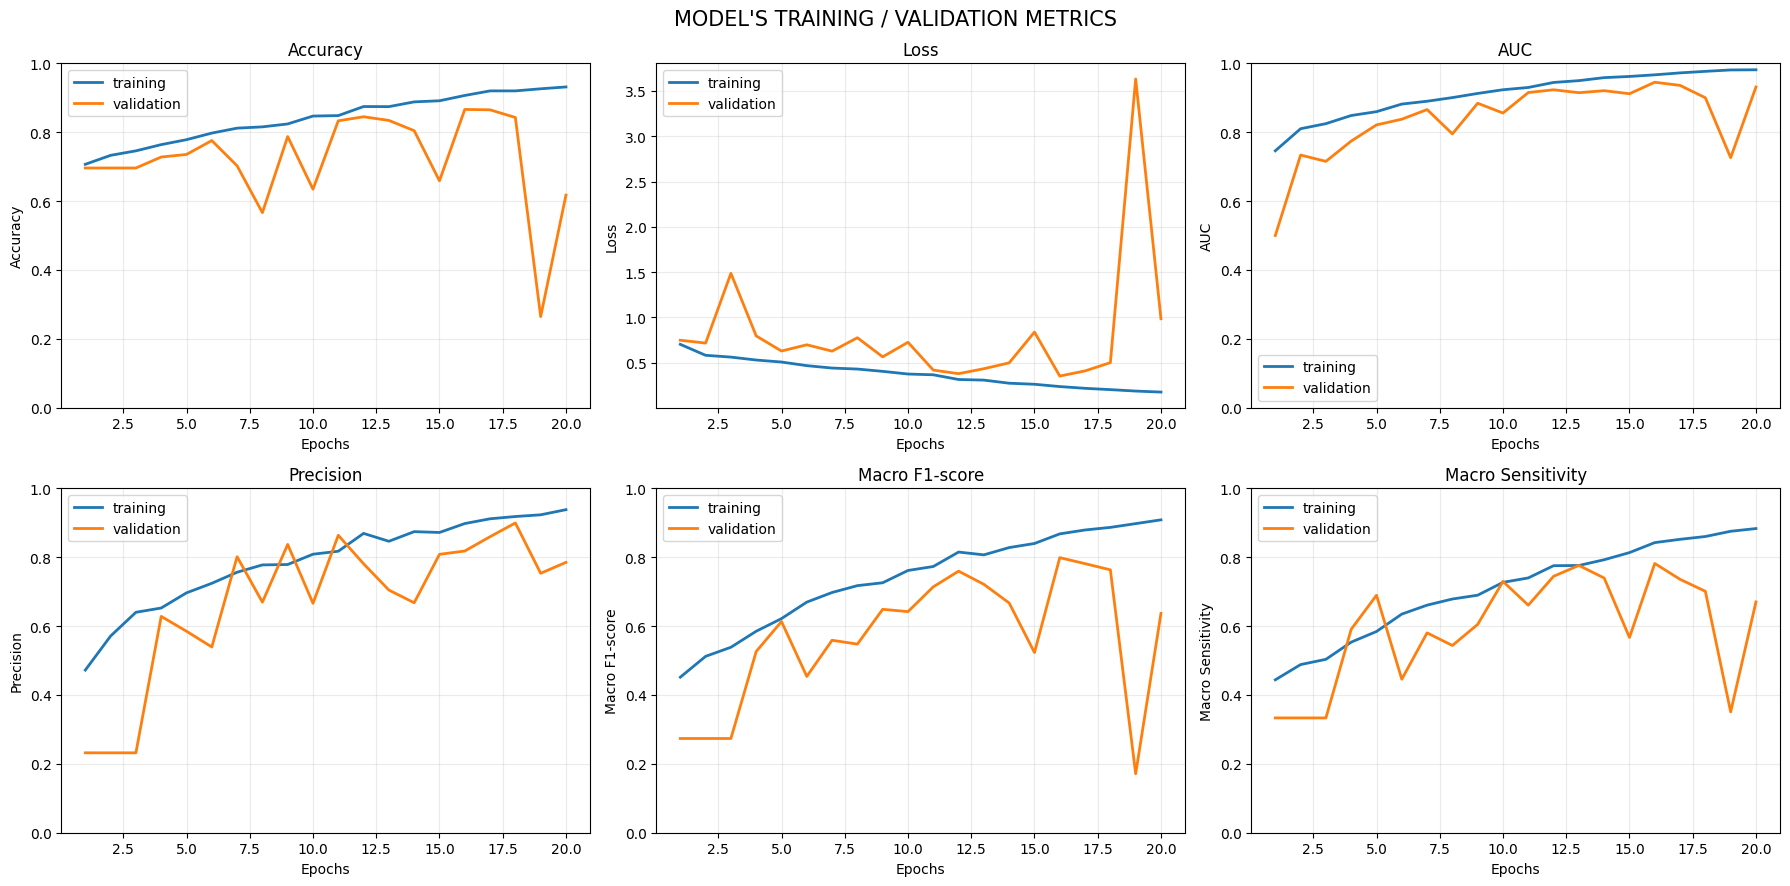

In [ ]:
Train_Val_Plot(
    history.history["accuracy"],
    history.history["val_accuracy"],

    history.history["loss"],
    history.history["val_loss"],

    history.history["auc"],
    history.history["val_auc"],

    history.history["precision"],
    history.history["val_precision"],

    history.history["f1_score"],
    history.history["val_f1_score"],

    history.history["sensitivity"],
    history.history["val_sensitivity"]
)


In [ ]:
import os
import tensorflow as tf
from tensorflow import keras

BEST_MODEL_PATH = best_checkpoint_path

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        "Best model checkpoint was not found:\n"
        + BEST_MODEL_PATH
    )


best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    compile=False
)

print("Best model loaded successfully.")
print("Checkpoint:", BEST_MODEL_PATH)


Best model loaded successfully.
Checkpoint: /content/lung_cancer_project/best_base_lung_cancer_model.keras


In [ ]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def convert_labels_to_class_indices(y_batch):

    y_batch = np.asarray(y_batch)

    if y_batch.ndim == 2:
        return np.argmax(
            y_batch,
            axis=1
        ).astype(np.int32)

    elif y_batch.ndim == 1:
        return y_batch.astype(np.int32)

    else:
        raise ValueError(
            f"Unexpected label shape: {y_batch.shape}"
        )


def predict_generator(model, generator):

    probabilities = []
    labels = []

    for i in range(len(generator)):

        X_batch, y_batch = generator[i]

        predictions = model.predict(
            X_batch,
            verbose=0
        )

        probabilities.extend(
            predictions.tolist()
        )

        batch_labels = convert_labels_to_class_indices(
            y_batch
        )

        labels.extend(
            batch_labels.tolist()
        )

    return (
        np.asarray(labels, dtype=np.int32),
        np.asarray(probabilities, dtype=np.float32)
    )


val_true, val_prob = predict_generator(
    best_model,
    val_gen
)

val_pred = np.argmax(
    val_prob,
    axis=1
)

val_accuracy = accuracy_score(
    val_true,
    val_pred
)

val_precision = precision_score(
    val_true,
    val_pred,
    average="macro",
    zero_division=0
)

val_sensitivity = recall_score(
    val_true,
    val_pred,
    average="macro",
    zero_division=0
)

val_f1 = f1_score(
    val_true,
    val_pred,
    average="macro",
    zero_division=0
)

try:
    val_auc = roc_auc_score(
        tf.keras.utils.to_categorical(
            val_true,
            NUM_CLASSES
        ),
        val_prob,
        multi_class="ovr",
        average="macro"
    )
except ValueError:
    val_auc = float("nan")


print("=" * 70)
print("VALIDATION RESULTS — THREE CLASSES")
print("=" * 70)

print("Validation samples :", len(val_true))
print("Accuracy            :", round(val_accuracy, 4))
print("Macro Precision     :", round(val_precision, 4))
print("Macro Sensitivity   :", round(val_sensitivity, 4))
print("Macro Recall        :", round(val_sensitivity, 4))
print("Macro F1            :", round(val_f1, 4))
print("Macro OVR AUC       :", round(val_auc, 4))

print("\nClassification Report:\n")

print(
    classification_report(
        val_true,
        val_pred,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


VALIDATION RESULTS — THREE CLASSES
Validation samples : 941
Accuracy            : 0.8661
Macro Precision     : 0.818
Macro Sensitivity   : 0.7818
Macro Recall        : 0.7818
Macro F1            : 0.7987
Macro OVR AUC       : 0.9464

Classification Report:

                         precision    recall  f1-score   support

         Adenocarcinoma     0.8961    0.9221    0.9090       655
   Large Cell Carcinoma     0.7632    0.6744    0.7160        43
Squamous Cell Carcinoma     0.7948    0.7490    0.7712       243

               accuracy                         0.8661       941
              macro avg     0.8180    0.7818    0.7987       941
           weighted avg     0.8639    0.8661    0.8646       941



In [ ]:

!pip install -q kagglehub

import os
import kagglehub


external_path = kagglehub.dataset_download(
    "mohamedhanyyy/chest-ctscan-images"
)

print("Downloaded dataset root:")
print(external_path)


possible_data_paths = []

for current_root, directories, files in os.walk(external_path):
    directory_names = {directory.lower() for directory in directories}

    if (
        "train" in directory_names
        and "test" in directory_names
        and ("valid" in directory_names or "validation" in directory_names)
    ):
        possible_data_paths.append(current_root)

if possible_data_paths:
    external_data_root = possible_data_paths[0]
else:
    # Fallback: search for a folder named Data
    data_candidates = []

    for current_root, directories, files in os.walk(external_path):
        for directory in directories:
            if directory.lower() == "data":
                data_candidates.append(os.path.join(current_root, directory))

    if not data_candidates:
        raise FileNotFoundError(
            "Could not locate the Data folder containing train, valid, and test."
        )

    external_data_root = data_candidates[0]

print("\nExternal data root:")
print(external_data_root)

print("\nExternal dataset structure:")
for current_root, directories, files in os.walk(external_data_root):
    level = current_root.replace(external_data_root, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(current_root)}/")

Downloaded dataset root:
/root/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1

External data root:
/root/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1/Data

External dataset structure:
Data/
    test/
        large.cell.carcinoma/
        adenocarcinoma/
        squamous.cell.carcinoma/
        normal/
    valid/
        squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/
        adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/
        normal/
        large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/
    train/
        squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/
        adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/
        normal/
        large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/


In [ ]:

external_test_df, external_bad_files = (
    validate_dataframe_files(
        external_test_df,
        name="final external test data"
    )
)

print("\nFinal external test size after validation:")
print(len(external_test_df))

for label, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name}:",
        int(
            (external_test_df["label"] == label).sum()
        )
    )

print(
    "Corrupt/unreadable files removed:",
    len(external_bad_files)
)



VALIDATING FINAL EXTERNAL TEST DATA
Original files : 130
Valid files    : 130
Corrupt files  : 0

Final external test size after validation:
130
Adenocarcinoma: 60
Large Cell Carcinoma: 25
Squamous Cell Carcinoma: 45
Corrupt/unreadable files removed: 0


In [ ]:

external_test_gen = MixedImageSequence(
    external_test_df,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

print(
    "External test batches:",
    len(external_test_gen)
)

print(
    "External test images:",
    len(external_test_df)
)


External test batches: 9
External test images: 130


In [ ]:

X_test_batch, y_test_batch = (
    external_test_gen[0]
)

print("X shape:", X_test_batch.shape)
print("X dtype:", X_test_batch.dtype)
print("X min:", X_test_batch.min())
print("X max:", X_test_batch.max())

print("y shape:", y_test_batch.shape)
print("y dtype:", y_test_batch.dtype)
print("y values:", np.unique(y_test_batch))

assert X_test_batch.shape[1:] == (
    IMG_SIZE,
    IMG_SIZE,
    3
)

assert np.all(
    np.isin(
        np.argmax(y_test_batch, axis=1),
        [0, 1, 2]
    )
)

print("\nExternal test generator is working correctly.")


X shape: (16, 224, 224, 3)
X dtype: float32
X min: 0.0
X max: 0.95686275
y shape: (16, 3)
y dtype: float32
y values: [0. 1.]

External test generator is working correctly.



FINAL EXTERNAL TEST RESULTS — THREE CLASSES
Total test images: 130
Adenocarcinoma: 60
Large Cell Carcinoma: 25
Squamous Cell Carcinoma: 45

Accuracy: 0.7231
Macro Precision: 0.7369
Macro Sensitivity: 0.7704
Macro Recall: 0.7704
Macro F1: 0.7218
Macro OVR AUC: 0.9301

Classification Report:

                         precision    recall  f1-score   support

         Adenocarcinoma     0.8000    0.6667    0.7273        60
   Large Cell Carcinoma     0.5319    1.0000    0.6944        25
Squamous Cell Carcinoma     0.8788    0.6444    0.7436        45

               accuracy                         0.7231       130
              macro avg     0.7369    0.7704    0.7218       130
           weighted avg     0.7757    0.7231    0.7266       130



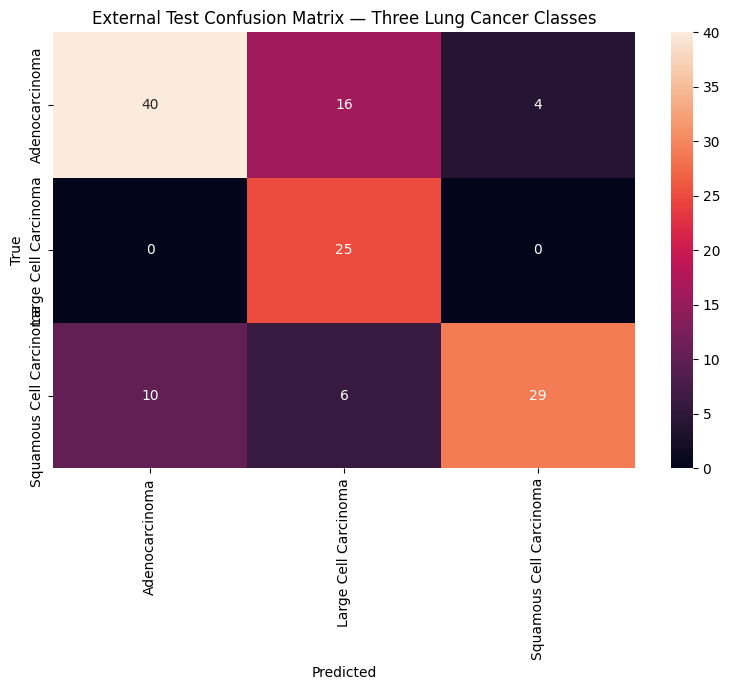


Per-class sensitivity:
Adenocarcinoma: 0.6667
Large Cell Carcinoma: 1.0000
Squamous Cell Carcinoma: 0.6444


In [ ]:

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import seaborn as sns
import matplotlib.pyplot as plt

test_true, test_prob = predict_generator(
    best_model,
    external_test_gen
)

test_pred = np.argmax(
    test_prob,
    axis=1
)


test_accuracy = accuracy_score(
    test_true,
    test_pred
)

test_precision = precision_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

test_sensitivity = recall_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

try:

    test_auc = roc_auc_score(
        tf.keras.utils.to_categorical(
            test_true,
            NUM_CLASSES
        ),
        test_prob,
        multi_class="ovr",
        average="macro"
    )

except ValueError:

    test_auc = float("nan")


print("\n" + "=" * 70)
print("FINAL EXTERNAL TEST RESULTS — THREE CLASSES")
print("=" * 70)

print(
    "Total test images:",
    len(test_true)
)

for label, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name}:",
        int(np.sum(test_true == label))
    )

print("\nAccuracy:", round(test_accuracy, 4))
print("Macro Precision:", round(test_precision, 4))
print("Macro Sensitivity:", round(test_sensitivity, 4))
print("Macro Recall:", round(test_sensitivity, 4))
print("Macro F1:", round(test_f1, 4))
print("Macro OVR AUC:", round(test_auc, 4))


print("\nClassification Report:\n")

print(
    classification_report(
        test_true,
        test_pred,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


cm = confusion_matrix(
    test_true,
    test_pred,
    labels=[0, 1, 2]
)

plt.figure(
    figsize=(8, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "External Test Confusion Matrix — Three Lung Cancer Classes"
)

plt.tight_layout()
plt.show()


print("\nPer-class sensitivity:")

per_class_sensitivity = recall_score(
    test_true,
    test_pred,
    labels=[0, 1, 2],
    average=None,
    zero_division=0
)

for class_name, sensitivity in zip(
    CLASS_NAMES,
    per_class_sensitivity
):

    print(
        f"{class_name}: {sensitivity:.4f}"
    )


In [ ]:


final_model_path = os.path.join(
    WORK_DIR,
    "lung_cancer_base_model_3class_20_epochs.keras"
)

model.save(final_model_path)

metrics_summary = pd.DataFrame([{
    "accuracy": test_accuracy,
    "macro_precision": test_precision,
    "macro_sensitivity": test_sensitivity,
    "macro_recall": test_sensitivity,
    "macro_f1": test_f1,
    "macro_ovr_auc": test_auc,
    "test_samples": len(test_true)
}])

metrics_path = os.path.join(
    WORK_DIR,
    "base_model_three_class_external_test_metrics.csv"
)

metrics_summary.to_csv(
    metrics_path,
    index=False
)

print("Final model saved to:")
print(final_model_path)

print("\nMetrics saved to:")
print(metrics_path)


Final model saved to:
/content/lung_cancer_project/lung_cancer_base_model_3class_20_epochs.keras

Metrics saved to:
/content/lung_cancer_project/base_model_three_class_external_test_metrics.csv
